 # Exploratory Data anlysis

 Objective : Given a new flower our objective is to identify weather it is setosa, versicolour or virginica


In [ ]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Read the CSV file
iris = pd.read_csv('/content/IRIS.csv')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris.shape #number of datapoints

(150, 5)

In [ ]:
iris.columns #what are the columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
# how many datapoints for each class are present?
# (OR) How many flowers for each variety are present?

iris['species'].value_counts()

# balanced data vs imbalanced data

# iris is a balanced dataset as the number of data points for every class is same

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


# 2D Plot

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

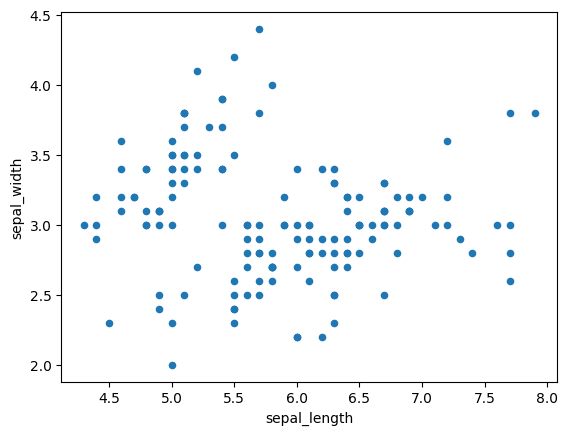

In [ ]:
# 2-D scatter plot

iris.plot(kind ='scatter', x='sepal_length', y='sepal_width')

# cannot make much sence out of it.
# what if we colour the points by thier class-label/flower-type

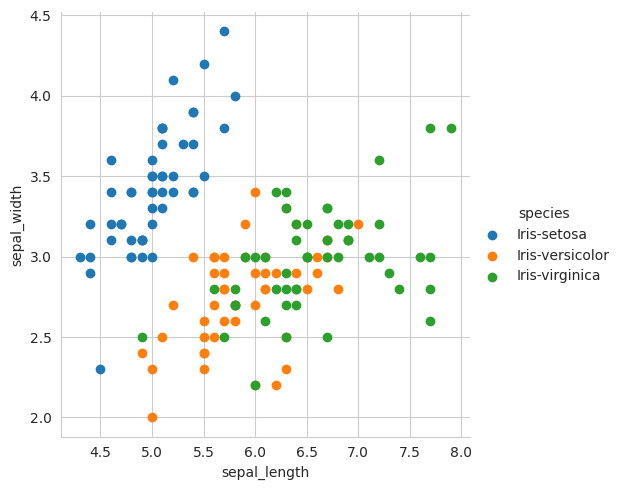

In [ ]:
# 2-D plot with colour coding for each flower type/class
# hue='species' color the plot by the variety
sns.set_style('whitegrid');
sns.FacetGrid(iris, hue='species',height=5)\
   .map(plt.scatter,'sepal_length','sepal_width')\
   .add_legend()
plt.show();

- Notice that the blue points can be easily seperated from the red and green by drawing a line.
But red and green data pointa cannot be easily seperated.
- Can we draw multiple 2-D scatter plots for each combination?
- How many combinations exist? 4C2 = 6

## Obervation(s):

1. Using sepal.lenth and sepal.width features, we can distinguish Sentosa from others. i.e Linerly Seperable

2. separating Versicolour from Virginica is mmuch harder than as they have considerable overlap.


# 3D Scatter plot
https://plot.ly/pandas/3d-scatter-plots/

needs a lot of mouce interaction to interpret data.

## Pair-plot

pairwise scatter plot: pairplot

**Disadvantages** :
- cannot be used when number of feature are high.
- cannot visualize higher dimentional patters in 3-D and 4-D
- only possible to view 2D patterns.



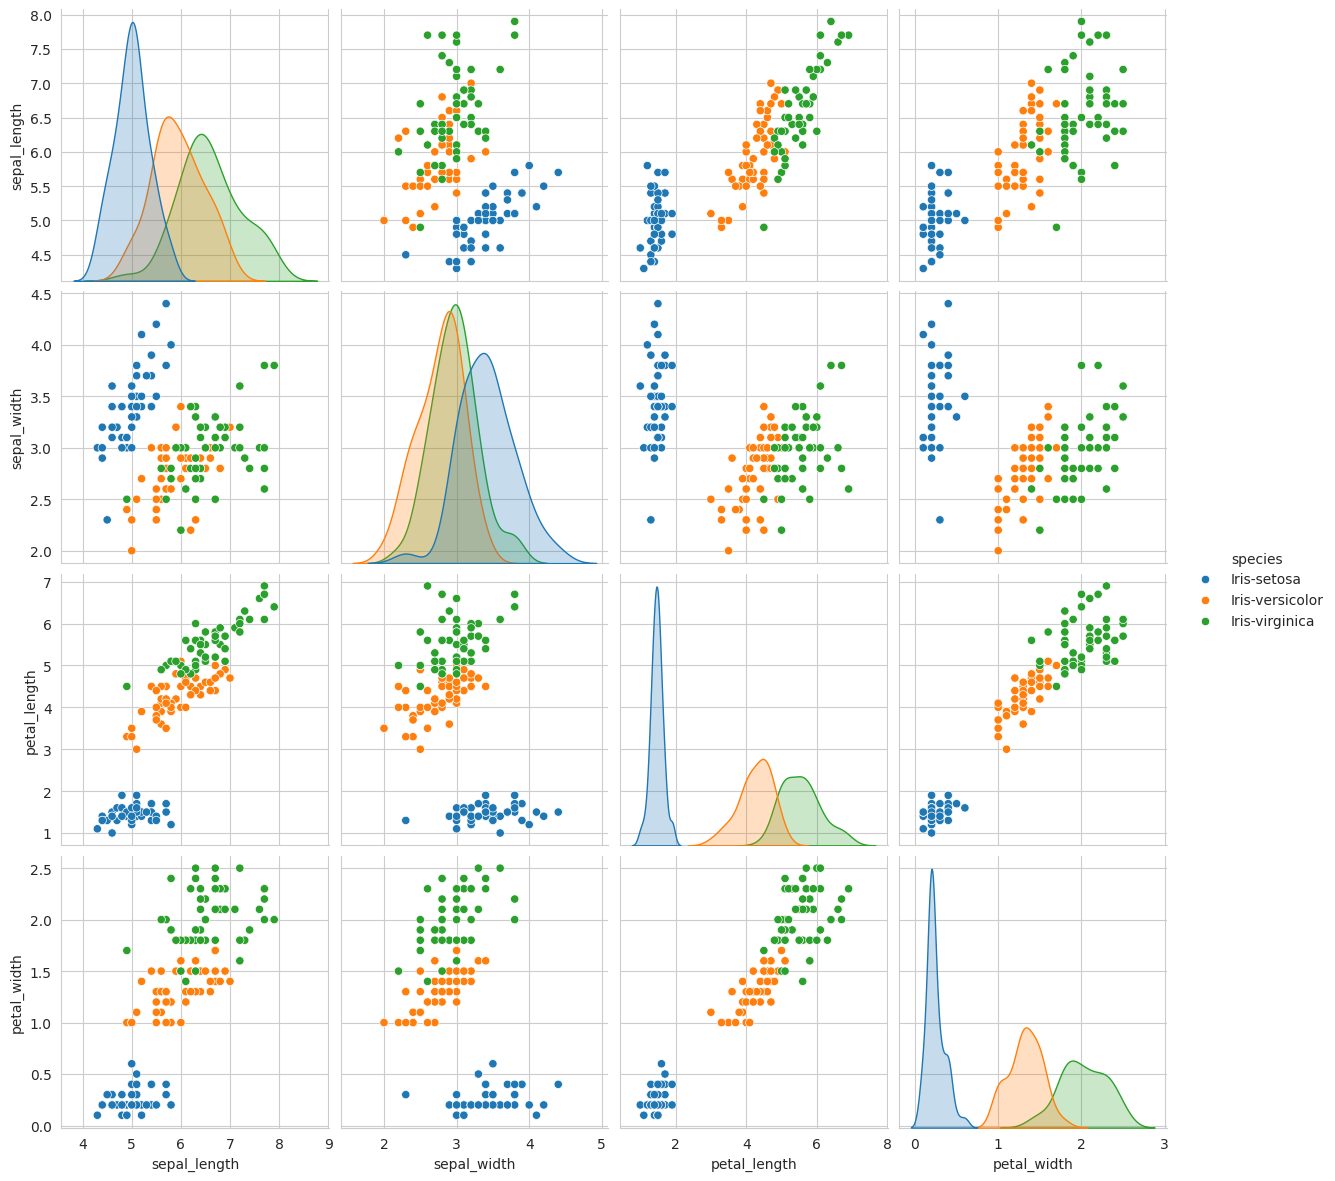

In [ ]:
#sns.set_style('whitegrid')
sns.pairplot(iris,hue='species',height=3);
plt.show()

**Note: The diagonal elements are PDF's for each feature.**

# obervation(s):
1. petal.lenght and petal.width are the most useful features to identify various flowers types.

2. While Sentosa can be easily identified(linearly seperable), Virnica and Versicolor have some overlap(almost linearly separable)

3. We can find "lines" and "if-else" conditions to build a simple model to classify the flower types.

# Limitations of pair-plot

- here in above example we had 4-dimentional data i.e(SL,SW,PL,PW) so 4C2 = 6

- if we have 10 features then, 10C2 and what if we have 100 features then, 100C2 these are a lot of plots to go through each plot and understand.

- pairplots are easy to understand when we have less number of features i.e (4,5,6)

- We need to use PCA, t-SNE to visualize a high dimentional data.



In [ ]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = iris.drop('species',axis=1)
y = iris['species']

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model = KNeighborsClassifier(n_neighbors=5,metric='euclidean')

model.fit(X,y)

KNeighborsClassifier(metric='euclidean')

In [ ]:
#predicting a new sample value
sample = np.array([4.5,3.2,1.6,0.5])
model.predict([sample])

array(['Iris-setosa'], dtype=object)

In [ ]:
model.score(X,y)

0.9666666666666667

In [ ]:
scores = []
for k in range(1,40):
  knn = KNeighborsClassifier(n_neighbors=k,metric='euclidean')
  knn.fit(X,y)
  scores.append(knn.score(X,y))
print(scores, end=" ")

[1.0, 0.98, 0.96, 0.96, 0.9666666666666667, 0.9733333333333334, 0.9733333333333334, 0.98, 0.98, 0.98, 0.9733333333333334, 0.98, 0.98, 0.98, 0.9866666666666667, 0.9866666666666667, 0.98, 0.9733333333333334, 0.98, 0.98, 0.98, 0.98, 0.98, 0.9733333333333334, 0.98, 0.9733333333333334, 0.9733333333333334, 0.9666666666666667, 0.9733333333333334, 0.9533333333333334, 0.96, 0.9533333333333334, 0.96, 0.96, 0.96, 0.9533333333333334, 0.96, 0.9466666666666667, 0.9533333333333334] 

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

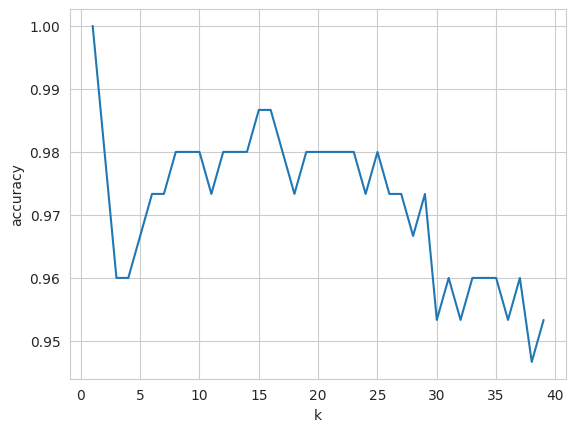

In [ ]:
plt.plot(range(1,40),scores)
plt.xlabel('k')
plt.ylabel('accuracy')
plt

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=15,metric='euclidean')
final_model.fit(X,y)

KNeighborsClassifier(metric='euclidean', n_neighbors=15)

In [ ]:
sample = np.array([4.5,3.2,1.6,0.5])
final_model.predict([sample])

array(['Iris-setosa'], dtype=object)

In [ ]:
final_model.score(X,y)

0.9866666666666667